# Lending Case Study
Lending Club Loan dataset contains information about past loan applicants and whether they are defaulted or not. The aim is to identify patterns that indicates if a person is likely to default. Based on this problem statement, data is anlysed and cleansed.

## Data Understanding

**Problem Statement**
- The primary objective of this analysis is to identify the key factors that predict loan default risk for Lending Club.

**Analysis Goals**

1. Pinpoint the key variables that are the most predictive of loan default.
2. Discover borrower groups with elevated probability of default.
3. Deliver practical recommendations to strengthen credit risk policies and decisioning.

**Data Quality Issues in Loan Dataset**
| Issue                     | Description                                   | Example                               |
|---------------------------|-----------------------------------------------|---------------------------------------|
| Missing values            | Many columns contain missing values           | mths_since_last_record, tax_liens     |
| Data entry errors         | Some column data have spelling mistakes       | home_ownership, purpose               |
| Non-standardised format   | Some columns have numerical values with units | term, int_rate, emp_length, zip_code  |
| Irrelevant columns        | Some columns are too descriptive in native    | url, desc, title                      |
| Same valued columns       | Some columns have the same data               | payment_loan, policy_code             |
| Unique identifier columns | Some columns are unique identifiers           | id, member_id                         |

### Import Libraries

In [298]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

### Data Load

In [299]:
df_loan = pd.read_csv('loan.csv', na_values=['NA', 'n/a'])
df_loan.head()

/var/folders/gv/nxc29ypd693dwh47bzhln46m0000gn/T/ipykernel_6955/2398227827.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df_loan = pd.read_csv('loan.csv', na_values=['NA', 'n/a'])


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


### Data before cleansing

In [300]:
df_loan.shape

(39717, 111)

## Data Cleansing and Manipulation

### Fixing Rows and Columns

**Fixing Rows**
- No summary rows.
- No incorrect header or footer rows.
- No extra rows like column number, indicators, blank rows, page no.

**Fixing Columns**
- Merging columns is not necessary since each column has its own purpose
- Column data transformation
    - `term` column contains values like '36 months'. This can be split to have only numeric values.
    - `int_rate` column also contains values like '10.65%'. This can be split to have only numeric values for easier calcultion.
    - Similarly `emp_length` and `zip_code` can also be standardised.
- No column names are missing.
- Column rename is not necessary since each column name has a meaning as described in the Data Dictionary.
- No misaligned columns

## Filter Data

- Removed the below unnecessary columns.
- Row removal and data aggregation might not be required.

    | Column Name                        | Reason for Deletion                  |
    |------------------------------------|--------------------------------------|
    | url, desc, title                   | Irrelevant/free text columns         |
    | application_type                   | often only one value                 |
    | emp_title                          | Free text                            |
    | payment_plan                       | Always 'n'                           |
    | mths_since_last_record             | Too many missing values              |
    | initial_list_status                | Only one value ('f' - franctional)   |
    | out_prncp, out_prncp_inv, total_pymnt, total_pymnt_inv, total_rec_prncp, total_rec_int | Post-loan metrics, NA |    
    | policy_code                        | Always '1'                           |
    | next_pymnt_d, last_credit_pull_d, last_pymnt_d, last_pymnt_amnt, total_rec_late_fee, collection_recovery_fee, recoveries | Post loan data, NA                    |
    | id, member_id                      | Unique identifiers                   |
    | total_il_high_credit_limit, total_bc_limit, total_bal_ex_mort, tot_hi_cred_lim, tax_liens, percent_bc_gt_75, pct_tl_nvr_dlq, num_tl_op_past_12m, num_tl_90g_dpd_24m, num_tl_30dpd, num_tl_120dpd_2m, num_sats, num_rev_tl_bal_gt_0, num_rev_accts, num_op_rev_tl, num_il_tl, num_bc_tl, num_bc_sats, num_actv_rev_tl, num_actv_bc_tl, num_accts_ever_120_pd, mths_since_recent_revol_delinq, mths_since_recent_inq, mths_since_recent_bc_dlq, mths_since_recent_bc, mort_acc, mo_sin_rcnt_tl, mo_sin_rcnt_rev_tl_op, mo_sin_old_rev_tl_op, mo_sin_old_il_acct, delinq_amnt, chargeoff_within_12_mths, bc_util, bc_open_to_buy, avg_cur_bal, acc_open_past_24mths, inq_last_12m, total_cu_tl, inq_fi, total_rev_hi_lim, all_util, max_bal_bc, open_rv_24m, open_rv_12m, il_util, total_bal_il, mths_since_rcnt_il, open_il_24m, open_il_12m, open_il_6m, open_acc_6m, tot_cur_bal, tot_coll_amt, acc_now_delinq, verification_status_joint, dti_joint, annual_inc_joint, mths_since_last_major_derog, collections_12_mths_ex_med | Columns have no values ('NA' or '0')          |
    

### Remove columns with no data

In [301]:
# check for columns with nan values, 
nan_columns = df_loan.columns[df_loan.isna().all()].tolist() # columns where all values are NaN

# colums where more than 50% values are NaN merge columns with nan_columns
missing_values = df_loan.isna().sum()

# check for 50% occurence of NaN values 
nan_columns = missing_values[missing_values > (0.5 * len(df_loan))].index.tolist()

# check if these columns exist in the dataframe
existing_nan_columns = [col for col in nan_columns if col in df_loan.columns]

# drop columns with NA missing values
df_loan.drop(existing_nan_columns, axis=1, inplace=True)

df_loan.head()


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,171.62,May-16,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,119.66,Sep-13,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,649.91,May-16,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,357.48,Apr-16,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,67.79,May-16,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0


### Remove irrelevant columns

In [302]:
# handling Irrevant/Redundant Columns: Some columns are added to deletion list during Data Analysis stage
irrelevant_columns = ['id', 'member_id', 'emp_title', 'url', 'desc', 'title', 'funded_amnt', 'funded_amnt_inv', 
                      'issue_d', 'inq_last_6mths', 'zip_code', 'addr_state', 'earliest_cr_line', 
                      'last_pymnt_d', 'last_credit_pull_d', 'verification_status','pymnt_plan', 
                      'acc_now_delinq', 'chargeoff_within_12_mths', 'application_type', 'initial_list_status', 
                      'policy_code', 'collections_12_mths_ex_med', 'delinq_amnt', 'tax_liens','pub_rec_bankruptcies',
                      'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
                      'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt']

# drop the irrelevant columns
df_loan.drop(columns=irrelevant_columns, inplace=True)

print(df_loan.columns)

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_length', 'home_ownership', 'annual_inc', 'loan_status', 'purpose',
       'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc'],
      dtype='object')


## Missing values
- Some columns such as mths_since_last_record have too many missing data, can be removed.
- Some columns have some data missing with annotations 'NA' or 'n/a' or empty. These are converted to numerical values.
- Standardise precision for float columns such as term, int_rate.
- Columns are scaled correctly.
- Removed extra characters such as units and 'xx' for zip_code.
- All text columns are standardised to lower case.

### Find columns with missing values

In [303]:
missingColumnValues = df_loan.isnull().sum()
missingColumnValues

loan_amnt            0
term                 0
int_rate             0
installment          0
grade                0
sub_grade            0
emp_length        1075
home_ownership       0
annual_inc           0
loan_status          0
purpose              0
dti                  0
delinq_2yrs          0
open_acc             0
pub_rec              0
revol_bal            0
revol_util          50
total_acc            0
dtype: int64

### Handle missing values for columns 

In [304]:
df_loan['emp_length'] = df_loan['emp_length'].fillna(0)
df_loan['revol_util'] = df_loan['revol_util'].fillna(0)

df_loan.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc
0,5000,36 months,10.65%,162.87,B,B2,10+ years,RENT,24000.0,Fully Paid,credit_card,27.65,0,3,0,13648,83.70%,9
1,2500,60 months,15.27%,59.83,C,C4,< 1 year,RENT,30000.0,Charged Off,car,1.00,0,3,0,1687,9.40%,4
2,2400,36 months,15.96%,84.33,C,C5,10+ years,RENT,12252.0,Fully Paid,small_business,8.72,0,2,0,2956,98.50%,10
3,10000,36 months,13.49%,339.31,C,C1,10+ years,RENT,49200.0,Fully Paid,other,20.00,0,10,0,5598,21%,37
4,3000,60 months,12.69%,67.79,B,B5,1 year,RENT,80000.0,Current,other,17.94,0,15,0,27783,53.90%,38


### Standardize the format of some columns and convert them to numeric type

In [305]:
df_loan['term'] = df_loan['term'].astype(str).str.replace(' months', '').str.strip().astype(int)
df_loan['int_rate'] = df_loan['int_rate'].astype(str).str.replace('%', '').str.strip().astype(float)
df_loan['revol_util'] = df_loan['revol_util'].astype(str).str.replace('%', '').str.strip().astype(float)

df_loan.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc
0,5000,36,10.65,162.87,B,B2,10+ years,RENT,24000.0,Fully Paid,credit_card,27.65,0,3,0,13648,83.7,9
1,2500,60,15.27,59.83,C,C4,< 1 year,RENT,30000.0,Charged Off,car,1.00,0,3,0,1687,9.4,4
2,2400,36,15.96,84.33,C,C5,10+ years,RENT,12252.0,Fully Paid,small_business,8.72,0,2,0,2956,98.5,10
3,10000,36,13.49,339.31,C,C1,10+ years,RENT,49200.0,Fully Paid,other,20.00,0,10,0,5598,21.0,37
4,3000,60,12.69,67.79,B,B5,1 year,RENT,80000.0,Current,other,17.94,0,15,0,27783,53.9,38


### Clean 'emp_length' column to remove text and convert to numeric

In [306]:
df_loan['emp_length'] = df_loan['emp_length'].astype(str).str.replace(' years', '').str.replace(' year', '').str.strip()
df_loan['emp_length'] = df_loan['emp_length'].replace({'< 1': '0', '10+': '10'}).astype(int)

df_loan['emp_length'].head()

0    10
1     0
2    10
3    10
4     1
Name: emp_length, dtype: int64

### Verify if there are no more missing values

In [307]:
missingColumnValues = df_loan.isnull().sum()
missingColumnValues

loan_amnt         0
term              0
int_rate          0
installment       0
grade             0
sub_grade         0
emp_length        0
home_ownership    0
annual_inc        0
loan_status       0
purpose           0
dti               0
delinq_2yrs       0
open_acc          0
pub_rec           0
revol_bal         0
revol_util        0
total_acc         0
dtype: int64

### Standardize precision for float columns

In [308]:
# Get data types of all columns to standardize precision for floats
df_loan.dtypes

loan_amnt           int64
term                int64
int_rate          float64
installment       float64
grade              object
sub_grade          object
emp_length          int64
home_ownership     object
annual_inc        float64
loan_status        object
purpose            object
dti               float64
delinq_2yrs         int64
open_acc            int64
pub_rec             int64
revol_bal           int64
revol_util        float64
total_acc           int64
dtype: object

In [309]:
# Standardize precision for float columns
df_loan['int_rate'] = df_loan['int_rate'].round(2)
df_loan['installment'] = df_loan['installment'].round(2)
df_loan['annual_inc'] = df_loan['annual_inc'].round(2)
df_loan['dti'] = df_loan['dti'].round(2)
df_loan['revol_util'] = df_loan['revol_util'].round(2)

df_loan.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc
0,5000,36,10.65,162.87,B,B2,10,RENT,24000.0,Fully Paid,credit_card,27.65,0,3,0,13648,83.7,9
1,2500,60,15.27,59.83,C,C4,0,RENT,30000.0,Charged Off,car,1.00,0,3,0,1687,9.4,4
2,2400,36,15.96,84.33,C,C5,10,RENT,12252.0,Fully Paid,small_business,8.72,0,2,0,2956,98.5,10
3,10000,36,13.49,339.31,C,C1,10,RENT,49200.0,Fully Paid,other,20.00,0,10,0,5598,21.0,37
4,3000,60,12.69,67.79,B,B5,1,RENT,80000.0,Current,other,17.94,0,15,0,27783,53.9,38


### Standardize text columns to lowercase

In [310]:
# Standardize text columns to lowercase
df_loan['home_ownership'] = df_loan['home_ownership'].str.lower()
df_loan['purpose'] = df_loan['purpose'].str.lower()
df_loan['loan_status'] = df_loan['loan_status'].str.lower()
df_loan['grade'] = df_loan['grade'].str.lower()
df_loan['sub_grade'] = df_loan['sub_grade'].str.lower()

df_loan.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc
0,5000,36,10.65,162.87,b,b2,10,rent,24000.0,fully paid,credit_card,27.65,0,3,0,13648,83.7,9
1,2500,60,15.27,59.83,c,c4,0,rent,30000.0,charged off,car,1.00,0,3,0,1687,9.4,4
2,2400,36,15.96,84.33,c,c5,10,rent,12252.0,fully paid,small_business,8.72,0,2,0,2956,98.5,10
3,10000,36,13.49,339.31,c,c1,10,rent,49200.0,fully paid,other,20.00,0,10,0,5598,21.0,37
4,3000,60,12.69,67.79,b,b5,1,rent,80000.0,current,other,17.94,0,15,0,27783,53.9,38


## Invalid Values
- Date columns needs to be formatted to standard dates. However, the date columns are irrelevant for defaults risk analysis and hence removed earlier.

## Cleansed Data Columns

| Variable Group      | Column Name           | Variable Type          | Description                                                        | Chosen for Analysis? |
|---------------------|----------------------|-----------------------|--------------------------------------------------------------------|----------------------|
| Target              | loan_status          | Categorical          | Current status of the loan (e.g., fully paid, charged off, current)| Yes                  |
| Borrower info       | emp_length           | Numerical             | Length of employment in years                  | Yes                   |
|                     | home_ownership       | Categorical           | Home ownership status (RENT, OWN, MORTGAGE, etc.)                 | Yes                  |
|                     | annual_inc           | Numerical             | Annual income reported by the borrower              | Yes                  |
| Loan characteristics| loan_amnt            | Numerical             | The listed amount of the loan applied for by the borrower              | Yes                  |
|                     | term                 | Numerical             | The number of payments on the loan (36 or 60 months)               | Yes                  |
|                     | int_rate             | Numerical             | Interest rate on the loan                                          | Yes                  |
|                     | grade                | Ordered categorical   | Lending Club assigned loan grade (A-G)                             | Yes                  |
|                     | sub_grade            | Ordered categorical   | Lending Club assigned loan subgrade (A1-G5)                        | Yes                  |
|                     | purpose              | Categorical           | A category provided by the borrower for the loan request           | Yes                  |
|                     | dti                  | Numerical             | Debt-to-Income ratio (considered in Grade calculation)             | Yes                  |
| Credit history      | earliest_cr_line     | Date                  | The month the borrower's earliest reported credit line was opened   | No                   |
|                     | inq_last_6mths       | Numerical             | Number of inquiries in the last 6 months                           | No                   |
|                     | mths_since_last_delinq| Numerical            | Months since the borrower's last delinquency                       | No                   |
|                     | open_acc             | Numerical             | Number of open credit lines in the borrower's credit file          | Yes                  |
|                     | pub_rec              | Numerical             | Number of derogatory public records                                | Yes                  |
|                     | total_acc            | Numerical             | Total number of credit lines currently in the borrower's file      | Yes                  |
|                     | pub_rec_bankruptcies | Numerical             | Number of public record bankruptcies                               | No                   |
| Payment history     | total_pymnt          | Numerical             | Payments received to date for the loan                             | No                   |
|                    | total_rec_prncp      | Numerical             | Principal received to date                                         | No                   |
|                    | total_rec_int        | Numerical             | Interest received to date                                          | No                   |
|                     | total_rec_late_fee   | Numerical             | Late fees received to date                                         | No                   |
|                    | recoveries           | Numerical             | Post charge off gross recovery                                     | No                   |
|                    | last_pymnt_d         | Date                  | Last month payment was received                                    | No                   |
|                        | last_pymnt_amnt      | Numerical             | Last payment amount received                                       | No                   |

## Data after cleansing

In [311]:
df_loan.shape

(39717, 18)

# Data Analysis

## Univariate Analysis

### Unordered categorical variables (purpose & home_ownership)

**Plot for purpose variable**
- Defaults falling under higher frequence purpose categories (such as debt_consolidation, credit_card) have bigger impact on overall loss

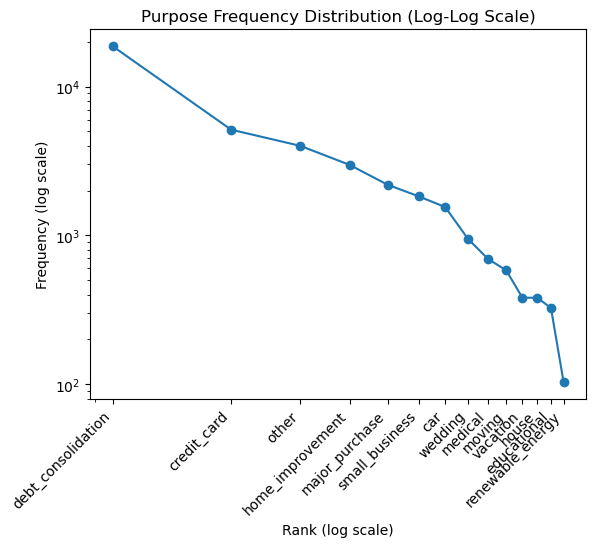

In [312]:
# Plot the frequency distribution of loan purposes on a log-log scale
freq = df_loan['purpose'].value_counts()
ranks = range(1, len(freq) + 1)

plt.figure()
plt.plot(ranks, freq.values, marker = 'o')
plt.xscale('log')
plt.yscale('log')
plt.title('Purpose Frequency Distribution (Log-Log Scale)')
plt.xlabel('Rank (log scale)')
plt.ylabel('Frequency (log scale)')
plt.xticks(ranks, freq.index, rotation=45, ha='right')
plt.show()

**Plot of home_ownership variable**
- Applicants with home rent or mortgage might have huge impact on loss if defaulted

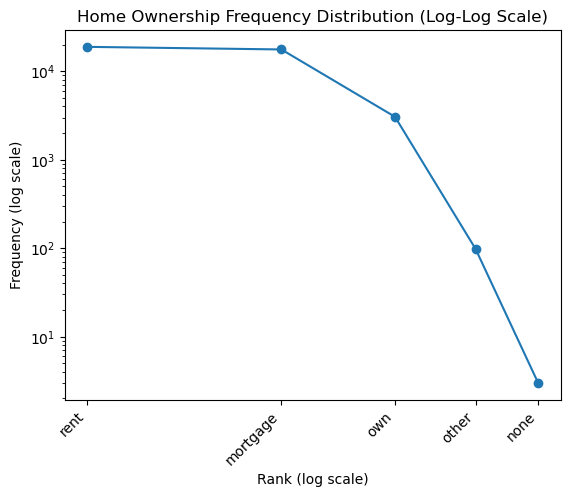

In [313]:
# Plot the frequency distribution of home ownership on a log-log scale
freq = df_loan['home_ownership'].value_counts()
ranks = range(1, len(freq) + 1)

plt.figure()
plt.plot(ranks, freq.values, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.title('Home Ownership Frequency Distribution (Log-Log Scale)')
plt.xlabel('Rank (log scale)')
plt.ylabel('Frequency (log scale)')
plt.xticks(ranks, freq.index, rotation=45, ha='right')
plt.show()

### Ordered categorical variables (Grade & Loan Status)

**Plot for grade variable**
- Loan grades of A and B need to be observed carefully since defaulters in these grades can impact overall profit/loss significantly

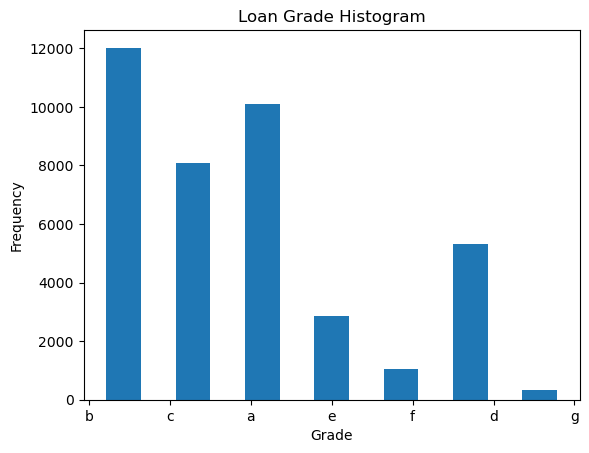

In [314]:
# Plot the histogram of loan grades
plt.figure()
plt.hist(df_loan['grade'], bins=len(df_loan['grade'].unique()), rwidth=0.5)
plt.title('Loan Grade Histogram')
plt.xlabel('Grade')
plt.ylabel('Frequency')
plt.xticks(sorted(df_loan['grade'].unique()))
plt.show()

**Plan for loan_status variable**
- From the loan statuses, we can eliminate the current loan holders since it has no value addition in risk analysis.
- We can use charged off and fully paid for bivariate analysis.
- Further, we can just use charged off for bivariate analysis for other variable combinations.

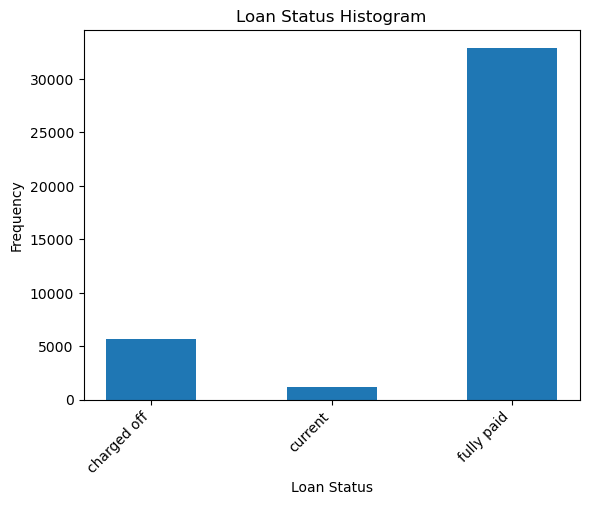

In [315]:
# Plot the histogram of loan status
counts = df_loan['loan_status'].value_counts().sort_index()
statuses = counts.index
frequencies = counts.values

plt.figure()
plt.bar(statuses, frequencies, width=0.5)
plt.title('Loan Status Histogram')
plt.xlabel('Loan Status')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Rotate for readability
plt.show()

### Numerical variables (Annual income & Loan amount)

**Plot for annual_inc variable**
- Outliers in annual income are cleaned using Interquartile range.
- After cleansing, it is found that the defaults in the range of 30k and 65k annual salary could lead to more loss since the data volume is high in this range.

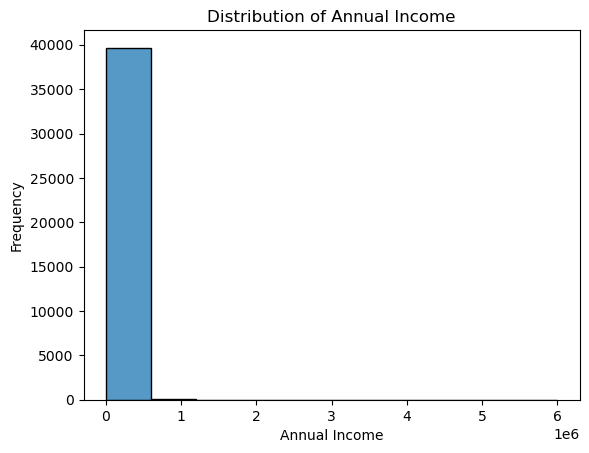

In [316]:
# Plot the distribution of annual income before removing outliers
sns.histplot(df_loan['annual_inc'], bins=10)
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.show()

In [317]:
# Identify and remove outliers in annual income using Interquartile method
Q1 = df_loan["annual_inc"].quantile(0.25)
Q3 = df_loan["annual_inc"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(IQR)
print(upper_bound)
print(lower_bound)

# Since data is higly skewed due to higher salary, remove data above upperbound
df_loan = df_loan[df_loan['annual_inc'] < upper_bound]
df_loan['annual_inc'].describe()

41896.0
145144.0
-22440.0


count     37874.000000
mean      61360.038960
std       28210.186388
min        4000.000000
25%       40000.000000
50%       56178.000000
75%       78000.000000
max      145008.000000
Name: annual_inc, dtype: float64

Text(0, 0.5, 'Frequency')

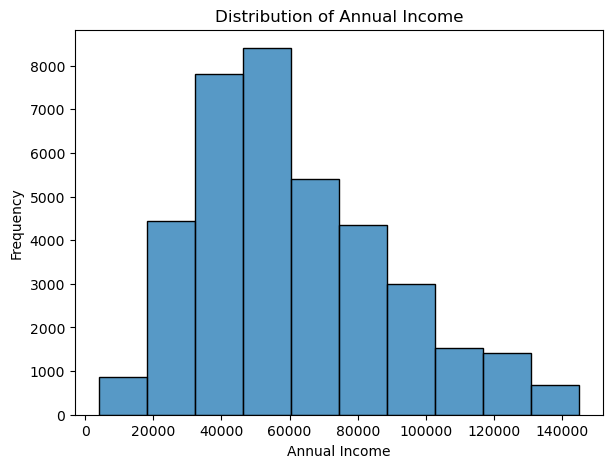

In [318]:
# Plot the distribution of annual income after removing outliers
plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
sns.histplot(df_loan['annual_inc'], bins=10)
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')

**Plot for loan_amount variable**
- Smaller loans are more common than larger loan amounts

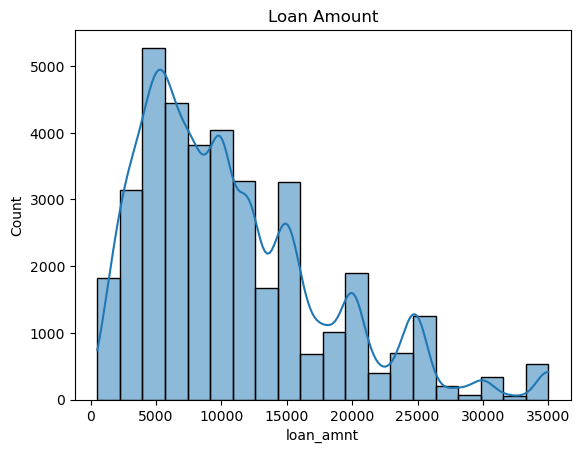

In [319]:
# Plot the distribution of loan amount
sns.histplot(df_loan['loan_amnt'], bins=20, kde=True)
plt.title('Loan Amount')
plt.show()

**Plot for int_rate variable**
- Lower interest rates are more common

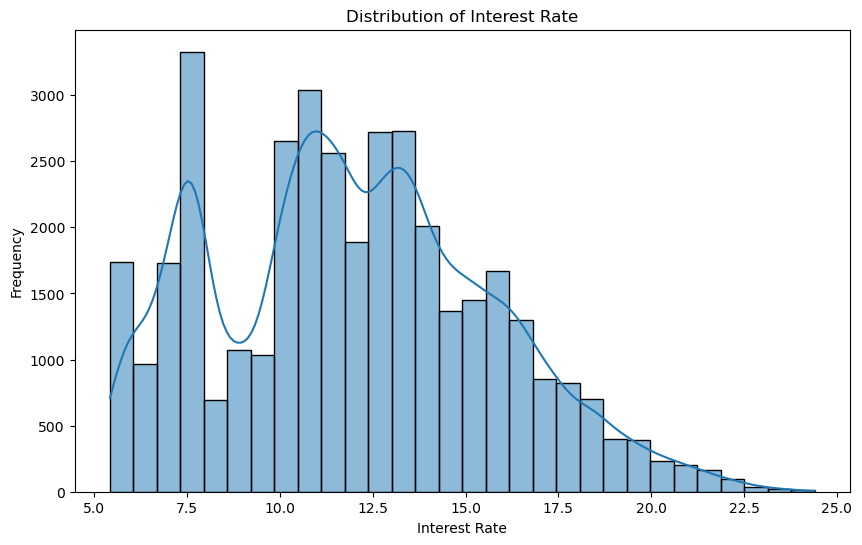

In [320]:
# Plot the distribution of interest rate
plt.figure(figsize=(10, 6))
sns.histplot(df_loan['int_rate'].dropna(), bins=30, kde=True)
plt.title('Distribution of Interest Rate')
plt.xlabel('Interest Rate')
plt.ylabel('Frequency') 
plt.show()

### Segmented Univariate Analysis

**Plot for purpose and loan_amnt**
- People who do small businesses go for higher loan. 
- Whenever the loan is high and the purpose is for small business or debt consolidation or house, bank can be extra cautious.

purpose
debt_consolidation    11000.0
small_business        10625.0
credit_card           10000.0
house                 10000.0
home_improvement       9000.0
wedding                8000.0
major_purchase         6000.0
medical                6000.0
other                  6000.0
renewable_energy       6000.0
car                    5900.0
educational            5000.0
moving                 5000.0
vacation               4525.0
Name: loan_amnt, dtype: float64


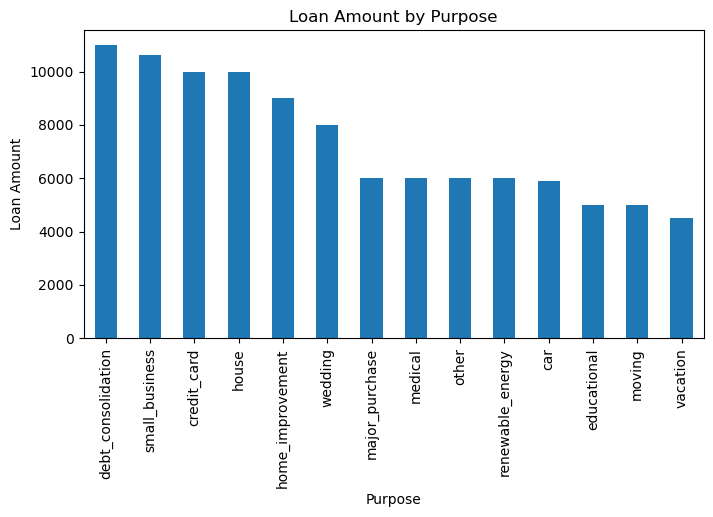

In [321]:
# Analyze median loan amount by purpose
median_income_by_home = df_loan.groupby('purpose')['loan_amnt'].median().sort_values(ascending=False)
print(median_income_by_home)

plt.figure(figsize=(8,4))
median_income_by_home.plot(kind='bar')
plt.title('Loan Amount by Purpose')
plt.xlabel('Purpose')
plt.ylabel('Loan Amount')
plt.show()

## Bivariate Analysis

### Target variable: loan_status
- Given: Loan status is a string variable
- Conversion: Converted loan status to numerical to plot graphs
- Exclusion: Current loan holders are excluded since it does not add any value

In [322]:
# Drop 'current' loan_status
df_loan = df_loan[~df_loan['loan_status'].str.lower().eq('current')]

# Create a binary target variable for default status
df_loan['is_default'] = df_loan['loan_status'].apply(lambda x: 1 if x == 'charged off' else 0)

**Default Vs Non-Default by purpose**
- Candidates of purpose small business are high likely to be defaulter
- We also saw earlier that candidates who do small purpose tend to take larger loans. So, bank need to be careful when providing larger loans for small businesses.

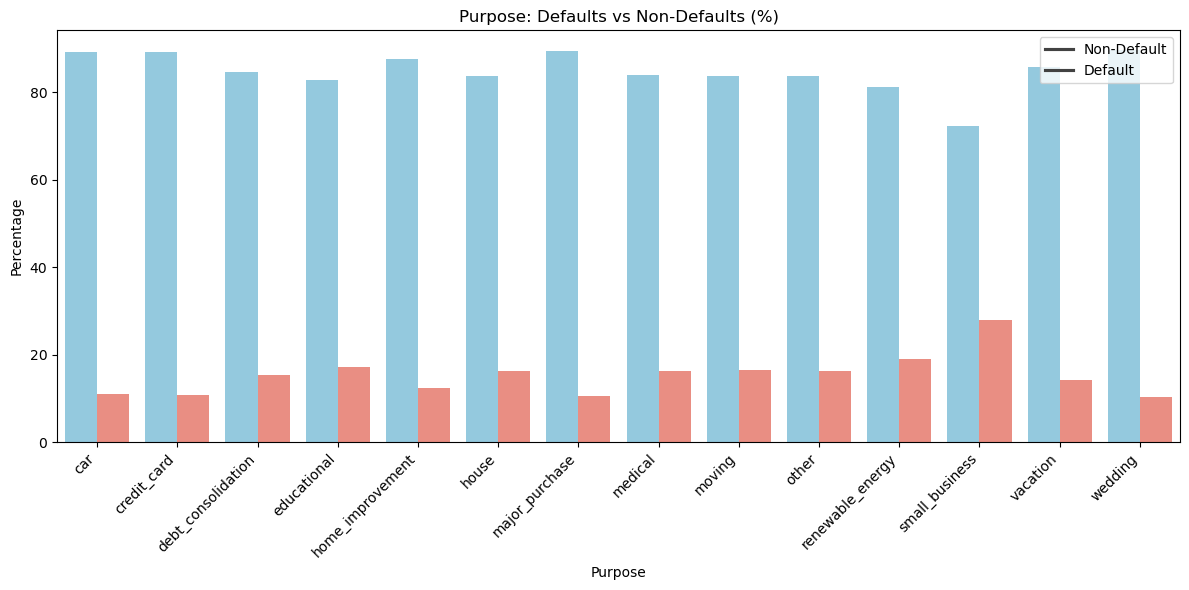

In [323]:
# Purpose (bar plot, percentage) - using df_loan after dropping 'current' loan_status
plt.figure(figsize=(12, 6))
purpose_counts = df_loan.groupby(['purpose', 'is_default']).size().reset_index(name='count')
purpose_totals = purpose_counts.groupby('purpose')['count'].transform('sum')
purpose_counts['percent'] = 100 * purpose_counts['count'] / purpose_totals

sns.barplot(
    x='purpose', y='percent', hue='is_default', data=purpose_counts,
    palette=['skyblue', 'salmon'], order=sorted(df_loan['purpose'].unique())
)

plt.title('Purpose: Defaults vs Non-Defaults (%)')
plt.xlabel('Purpose')
plt.ylabel('Percentage')
plt.legend(['Non-Default', 'Default'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Plots for grade and sub-grade variables for defaults**
- Defaulters increase as the grades or sub-grades increase.
- Highest defaulters are from grade 'G' (sub-grades 'G3', 'G5')
- High defaulters can also be found in sub-grade 'F5'.

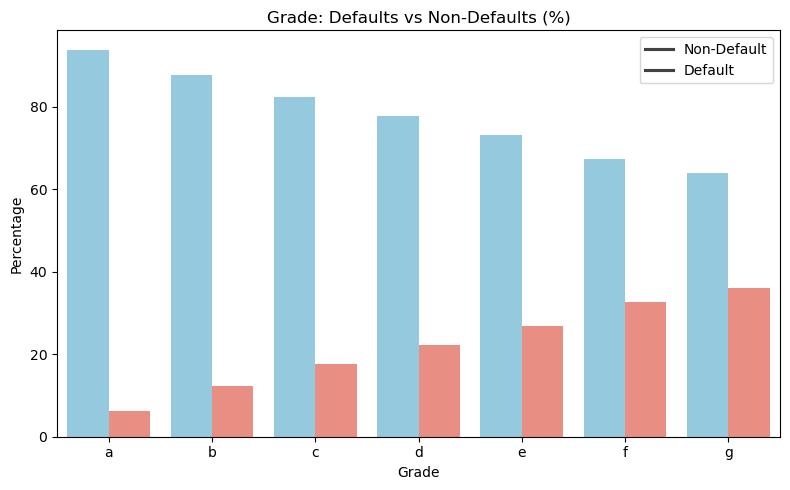

In [324]:
# Grade (bar plot, percentage)
plt.figure(figsize=(8, 5))
grade_counts = df_loan.groupby(['grade', 'is_default']).size().reset_index(name='count')
grade_totals = grade_counts.groupby('grade')['count'].transform('sum')
grade_counts['percent'] = 100 * grade_counts['count'] / grade_totals

sns.barplot(
    x='grade', y='percent', hue='is_default', data=grade_counts,
    palette=['skyblue', 'salmon'], order=sorted(df_loan['grade'].unique())
)

plt.title('Grade: Defaults vs Non-Defaults (%)')
plt.xlabel('Grade')
plt.ylabel('Percentage')
plt.legend(['Non-Default', 'Default'])
plt.tight_layout()
plt.show()


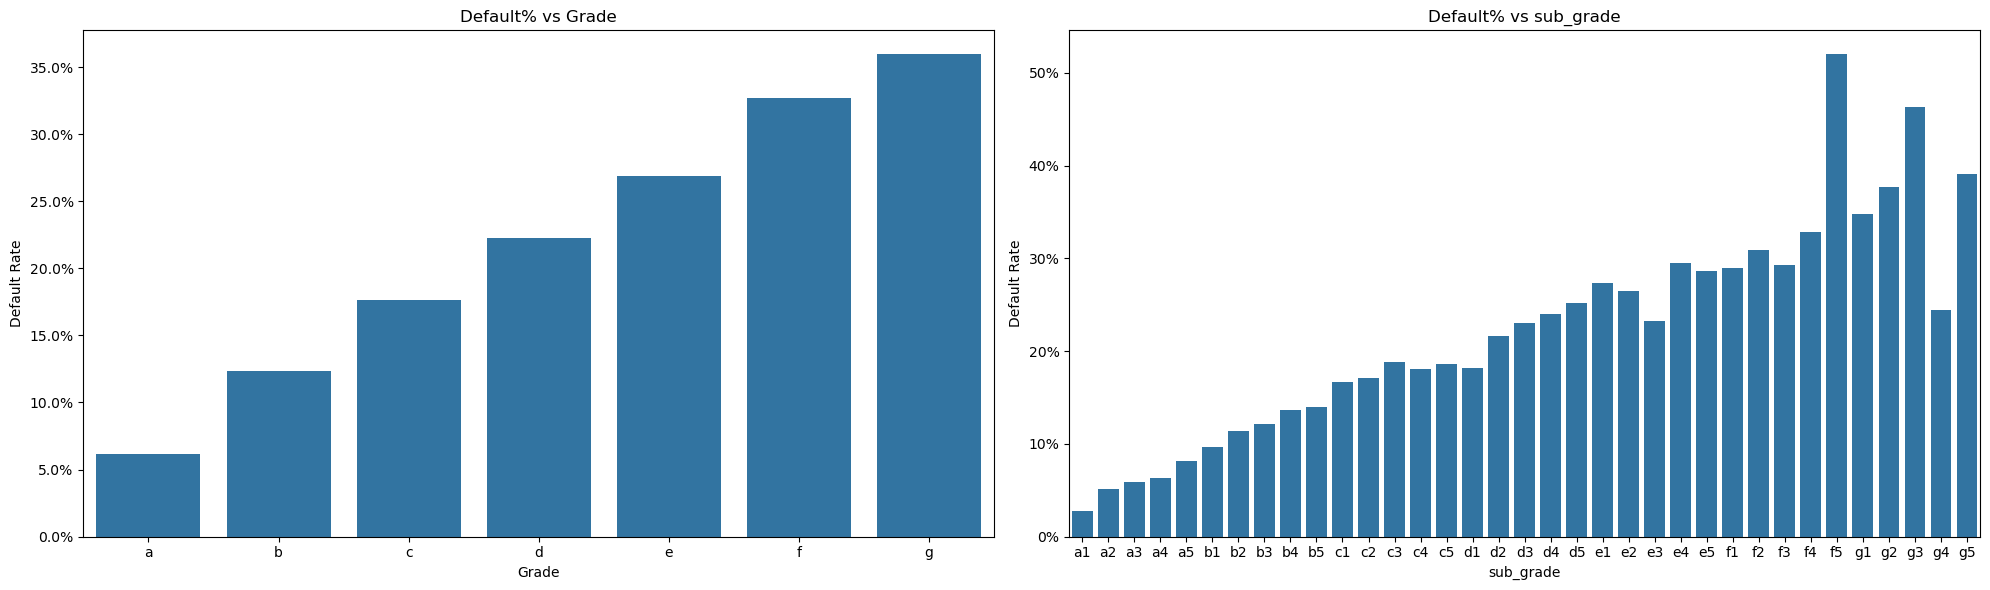

In [325]:
# Default Rate by Grade
plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)
grade_default_rate = df_loan.groupby('grade')['is_default'].mean().reset_index()
sns.barplot(x='grade', y='is_default', data=grade_default_rate, order=sorted(df_loan['grade'].unique()))
plt.title('Default% vs Grade')
plt.ylabel('Default Rate')
plt.xlabel('Grade')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

# Default Rate by Sub-Grade
plt.subplot(1, 2, 2)
sub_grade_default_rate = df_loan.groupby('sub_grade')['is_default'].mean().reset_index()
sns.barplot(x='sub_grade', y='is_default', data=sub_grade_default_rate, order=sorted(df_loan['sub_grade'].unique()))
plt.title('Default% vs sub_grade')
plt.ylabel('Default Rate')
plt.xlabel('sub_grade')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout()
plt.show()


**Default rate by home ownership**
- Candidates under None category fall more as defaulters.
- However, there is no significant different in defaulter rate among other categories as well.
- Hence, home ownership plays no vital role in risk analysis.

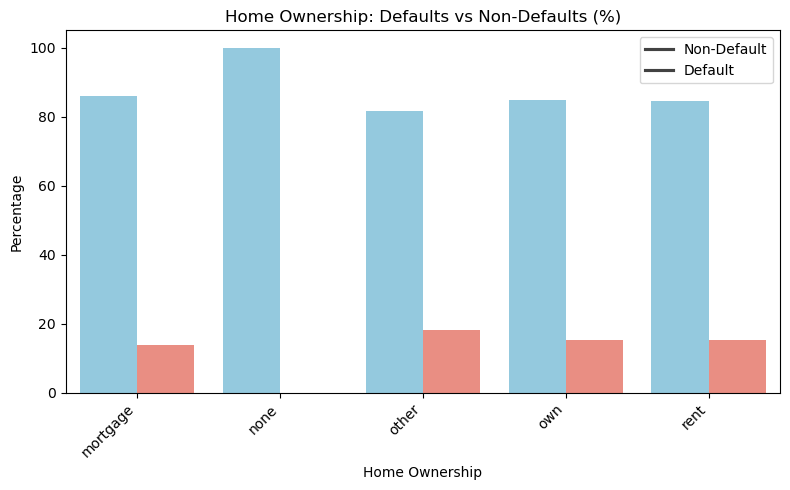

In [326]:
# Home Ownership (bar plot, percentage) - using df_loan after dropping 'current' loan_status
plt.figure(figsize=(8, 5))
home_counts = df_loan.groupby(['home_ownership', 'is_default']).size().reset_index(name='count')
home_totals = home_counts.groupby('home_ownership')['count'].transform('sum')
home_counts['percent'] = 100 * home_counts['count'] / home_totals

sns.barplot(
    x='home_ownership', y='percent', hue='is_default', data=home_counts,
    palette=['skyblue', 'salmon'], order=sorted(df_loan['home_ownership'].unique())
)

plt.title('Home Ownership: Defaults vs Non-Defaults (%)')
plt.xlabel('Home Ownership')
plt.ylabel('Percentage')
plt.legend(['Non-Default', 'Default'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Plot for defaults and non-defaults by DTI**
- Higher and more variable DTI is associated with increased default risk.
- Grade is determined by considering DTI as well, hence we will prioritise Grade variable over DTI variable.

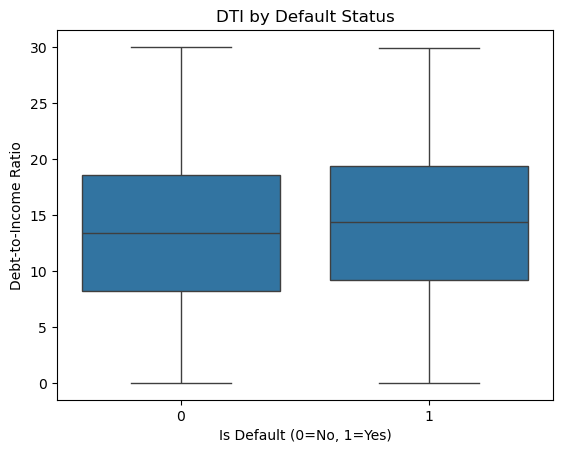

In [327]:
sns.boxplot(x='is_default', y='dti', data=df_loan)
plt.title('DTI by Default Status')
plt.xlabel('Is Default (0=No, 1=Yes)')
plt.ylabel('Debt-to-Income Ratio')
plt.show()

In [328]:
# Calculate IQR for DTI for defaulters and non-defaulters
for label, group in df_loan.groupby('is_default'):
    Q1 = group['dti'].quantile(0.25)
    Q3 = group['dti'].quantile(0.75)
    IQR = Q3 - Q1
    print(f"Is Default = {label}: Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")

Is Default = 0: Q1 = 8.19, Q3 = 18.58, IQR = 10.389999999999999
Is Default = 1: Q1 = 9.18, Q3 = 19.4, IQR = 10.219999999999999


**Plot for defaults and non-defaults by loan amount**
- The higher the loan amount, the more defaulters.

/var/folders/gv/nxc29ypd693dwh47bzhln46m0000gn/T/ipykernel_6955/388092093.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate_by_loan_amnt = df_loan.groupby('loan_amnt_bin')['is_default'].mean()


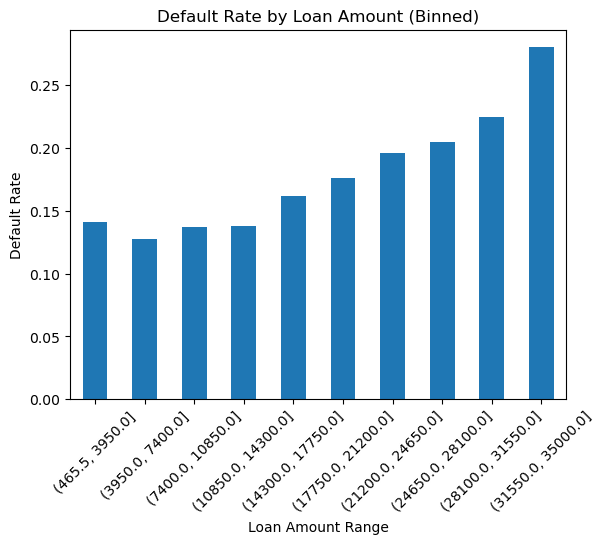

In [329]:
df_loan['loan_amnt_bin'] = pd.cut(df_loan['loan_amnt'], bins=10)
default_rate_by_loan_amnt = df_loan.groupby('loan_amnt_bin')['is_default'].mean()

plt.figure()
default_rate_by_loan_amnt.plot(kind='bar')
plt.title('Default Rate by Loan Amount (Binned)')
plt.xlabel('Loan Amount Range')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.show()

**Heatmap for defaults based on Grade and Purpose**
- We have seen the importance of Grade variable, hence plotting heatmap with grade and other variables to get more insights.
- Highest risk combinations based on defaults with Grade and Purpose:
    - Grade 'G' has the highest default rates across almost all purposes.
    - Purposes with especially high default rates: 'Renewable energy', 'Medical', 'Small business', 'House', 'Car'.

    | Purpose            | High Risk Grades  |
    |--------------------|-------------------|
    | renewable energy   | F, G              |
    | medical            | F, G              |
    | small business     | D, E, F, G        |
    | house              | F, G              |
    | car                | F, G              |

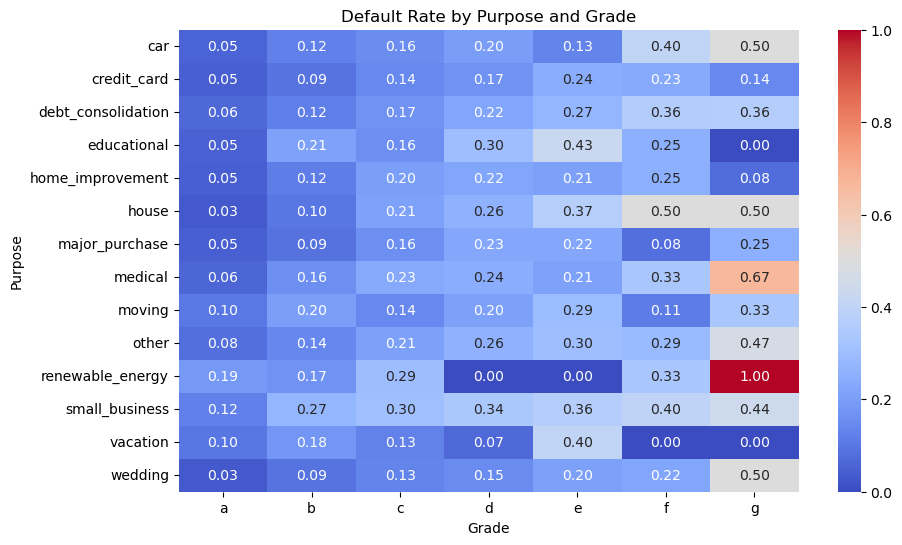

In [330]:
# HeatMap for defaults by Purpose and Grade
pivot = pd.pivot_table(df_loan, values='is_default', index='purpose', columns='grade', aggfunc='mean')
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Default Rate by Purpose and Grade')
plt.ylabel('Purpose')
plt.xlabel('Grade')
plt.show()

**Heatmap for defaults based on Grade and Purpose**
- Default rates generally increase with higher loan amount bins for most purposes.
- 'Medical' purpose is highly risky combined with large loan amount.
- 'Educational' and 'Small business' purposes combined with large loan amounts are also riskier.

| Purpose            | Loan Amount Bin(s) with Highest Default Rate | Default Rate Trend with Loan Amount|
|--------------------|---------------------------------------------|-------------------------------------|
| small business     | Highest bins (largest loans)                | Increases sharply with loan amount  |
| medical            | High bins                                   | Increases with loan amount          |
| educational        | High bins                                   |                                     |

/var/folders/gv/nxc29ypd693dwh47bzhln46m0000gn/T/ipykernel_6955/183346619.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(df_loan, values='is_default', index='purpose', columns='loan_amnt_bin', aggfunc='mean')


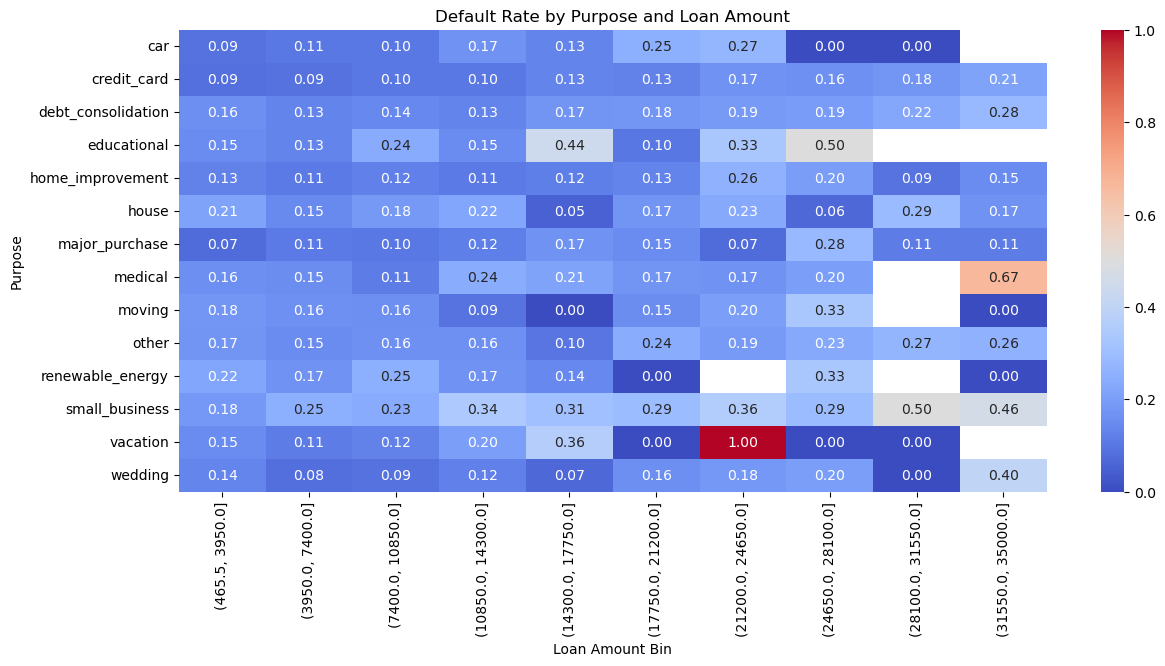

In [331]:
# Heatmap Purpose vs Loan Amount (binned)
pivot = pd.pivot_table(df_loan, values='is_default', index='purpose', columns='loan_amnt_bin', aggfunc='mean')
plt.figure(figsize=(14,6))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Default Rate by Purpose and Loan Amount')
plt.ylabel('Purpose')
plt.xlabel('Loan Amount Bin')
plt.show()

/var/folders/gv/nxc29ypd693dwh47bzhln46m0000gn/T/ipykernel_6955/2581492808.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  annual_inc_purpose_rate = default_df.groupby(['annual_inc_bin', 'purpose']).size().unstack(fill_value=0)


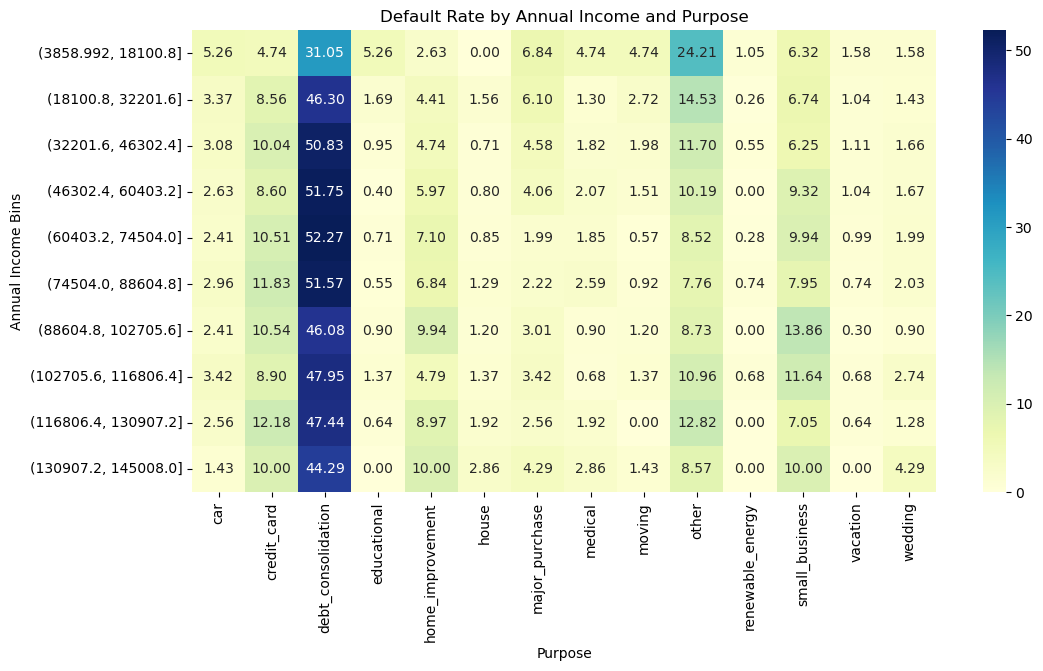

In [332]:
if 'annual_inc_bin' not in df_loan.columns:
    df_loan['annual_inc_bin'] = pd.cut(df_loan['annual_inc'], bins=10)

# Filter for defaults (is_default == 1), not loan_status == 0
default_df = df_loan[df_loan['is_default'] == 1]

# Group and calculate default rate
annual_inc_purpose_rate = default_df.groupby(['annual_inc_bin', 'purpose']).size().unstack(fill_value=0)

# Only plot if there is data
if not annual_inc_purpose_rate.empty:
    annual_inc_purpose_rate = (annual_inc_purpose_rate.T / annual_inc_purpose_rate.T.sum()).T * 100
    plt.figure(figsize=(12, 6))
    sns.heatmap(annual_inc_purpose_rate, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title('Default Rate by Annual Income and Purpose')
    plt.xlabel('Purpose')
    plt.ylabel('Annual Income Bins')
    plt.show()

**Correlation Matrix**
- Default rate shows possitive correlation with 'loan amount', 'int rate', 'term'.

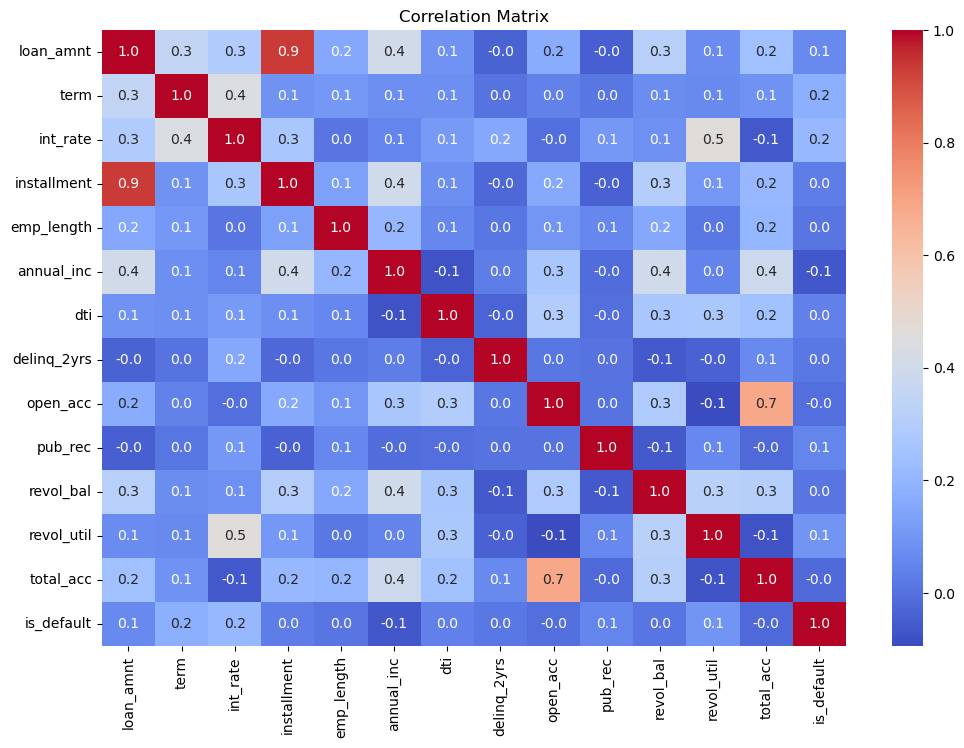

In [333]:
# Compute correlation matrix
numeric_df = df_loan.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Conclusion

## Conclusions: Potential Risk Variables Contributing to Loan Defaults

Based on the analysis in the notebook, the following variables are identified as key contributors to loan default risk:

### 1. **Loan Grade and Sub-Grade**
- Default rates increase significantly with lower grades (especially F and G).
- Sub-grades G3, G5, and F5 show the highest default rates.
- Grade is a strong summary indicator of risk, as it incorporates multiple borrower and loan characteristics.

### 2. **Loan Purpose**
- Certain purposes are consistently associated with higher default rates, especially:
  - **Small business**
  - **Renewable energy**
  - **Medical**
  - **House**
  - **Educational**
- These purposes are even riskier when combined with large loan amounts or low grades.

### 3. **Loan Amount**
- Higher loan amounts are associated with higher default rates across most purposes.
- The risk is especially pronounced for small business, renewable energy, and medical loans at higher amounts.

### 4. **Interest Rate**
- Higher interest rates are correlated with higher default rates.
- This is expected, as riskier borrowers are charged higher rates.

### 5. **Annual Income**
- While most defaults occur in the 30k–65k income range (due to volume), lower income alone is not a strong predictor after controlling for other variables.

### **Summary Table: High Risk Combinations**

| Purpose            | High Risk Grades   | High Risk Loan Amounts      |
|--------------------|-------------------|-----------------------------|
| small business     | D, E, F, G        | Highest bins (largest loans)|
| renewable energy   | F, G              | Highest bins                |
| medical            | F, G              | High bins                   |
| house              | F, G              | High bins                   |
| educational        | F, G              | High bins                   |

## Recommendation 

Lending policies should be more conservative for loans with 
- low grades, 
- high loan amounts, 
- high-risk purposes (especially small business, renewable energy, and medical). 

These combinations have the highest observed default rates.